In [1]:
import joblib # for saving the model
import sys # for checking what environment user is working in
import numpy as np
from PIL import Image # preprocessing
from torchvision import transforms # preprocessing

# model selections
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [7]:
print(sys.executable)

c:\Users\laika\OneDrive\Documents\Capstone I\.venv\Scripts\python.exe


In [9]:
from capstone_data.image_loader import load_dataset # custom helper functions built by Mike!
from collections import Counter # custom helper functions built by Mike!

DATA_PATH = r"C:\Users\laika\OneDrive\Documents\Capstone I\MyWorkspaceLP\cleaned_data"
dataset = load_dataset(DATA_PATH)
print(f"Total Images: {len(dataset)}")
print(f"First Record: {dataset[0]}")

print("\nImages per class:")
class_counts = Counter(item['class_name'] for item in dataset)

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Total Images: 16779
First Record: {'path': WindowsPath('C:/Users/laika/OneDrive/Documents/Capstone I/MyWorkspaceLP/cleaned_data/angry_clean/angry_cleaned_test/PrivateTest_10131363.jpg'), 'label': 0, 'class_name': 'angry'}

Images per class:
angry: 3089
happy: 6677
sad: 1207
neutral: 5806


In [12]:
# First we make a pandas dataframe from the list (dataset)
import pandas as pd
data_frame = pd.DataFrame(dataset)
data_frame.columns

Index(['path', 'label', 'class_name'], dtype='str')

In [13]:
labels = [x for x in data_frame['label'].unique()]
labels # labels are represented as integers here

[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

In [14]:
# define augment params first
augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(size=(48,48), scale=(0.9, 1.0)),
])

# create an empty list for the x,y arrays
x=[];y=[]
total=len(data_frame)
for item in data_frame['label'].items():
    # Progress bar
    percent = 100 * item[0] / total
    bar_length = 30
    filled = int(bar_length * item[0] / total)
    bar = "=" * filled + "-" * (bar_length - filled)
    
    print(f"\r[{bar}] {percent:6.2f}% ({item[0]}/{total})", end="")
    
    path = data_frame['path'].iloc[item[0]]
    try:
        with Image.open(path) as img:
            img = img.convert("L") # convert to Black & White for consistency
            img = img.resize((48,48)) # convert to 48x48 for consistency
            img_data = np.array(img)

            x.append(img_data)
            y.append(item[1])

            # Augmented Image
            aug_img = augment(img)
            aug_data = np.array(aug_img)

            x.append(aug_data)
            y.append(item[1])
    except Exception as e:
        print(f"Skipped {filename} due to: {e}")

# put all data into numpy arrays
x=np.array(x);y=np.array(y)

# flattens the images in preperation for splitting
X = x.reshape(x.shape[0], -1)
print()
print(X.shape)
print(y.shape)

[=============================-]  99.99% (16778/16779)
(33558, 2304)
(33558,)


In [15]:
# Train/Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y
                                                    )
split_data = dict(
                zip(
                    ['X_train', 'X_test', 'y_train', 'y_test'],
                    (X_train, X_test, y_train, y_test)
                )
            )
# print the distribution of splitted data to check if it worked correctly
for label, array in split_data.items():
    print(f"{label}: {array.shape}")

X_train: (26846, 2304)
X_test: (6712, 2304)
y_train: (26846,)
y_test: (6712,)


In [17]:
from sklearn.ensemble import RandomForestClassifier
# Define the pipeline here, fit the data, print a classification report
pipe = Pipeline([
    ('classifier', RandomForestClassifier(max_depth=None, n_estimators=100, random_state=42,n_jobs=-1))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Angry', 'Happy', 'Sad', 'Neutral']))

              precision    recall  f1-score   support

       Angry       0.64      0.22      0.33      1236
       Happy       0.64      0.83      0.72      2671
         Sad       0.89      0.05      0.09       483
     Neutral       0.59      0.71      0.65      2322

    accuracy                           0.62      6712
   macro avg       0.69      0.45      0.45      6712
weighted avg       0.64      0.62      0.58      6712



In [18]:
cm = confusion_matrix(y_test, y_pred, labels=[0,1,2,3])

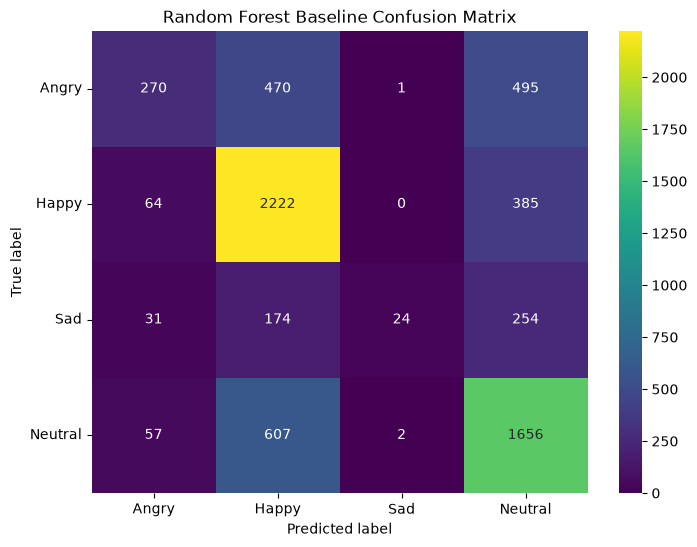

In [20]:
# use seaborn and matplotlib to plot
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['Angry', 'Happy', 'Sad', 'Neutral']

plt.figure(figsize=(8,6))

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='viridis',
xticklabels=class_names,
yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.yticks(rotation=360)
plt.title("Random Forest Baseline Confusion Matrix")
plt.savefig("Conf_Matrix.png")
plt.show()

In [21]:
# save the model with joblib
joblib.dump(pipe, 'random_forest_baseline.joblib')

['random_forest_baseline.joblib']